In [36]:
#!/usr/bin/env python
# coding: utf-8

In [37]:
import scipy.io
import os
import sys
import h5py
import numpy as np
from scipy.interpolate import interp1d
import torch
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sbi import utils as sbi_utils
from sbi.inference import SNPE
from sbi.utils.get_nn_models import posterior_nn
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import random

# Set seeds for reproducibility
random.seed(42)  # For Python's built-in random module
np.random.seed(42)  # For NumPy
# Optionally, set TensorFlow to deterministic mode for even more reproducibility
os.environ['TF_DETERMINISTIC_OPS'] = '1'

In [38]:
name_format = "GBM_Hist_UQtest"
print("Note: use results16.mat which has 10000 datasets; B only has positive Z values; Poisson noise added; 90, 0.12, 14")
file_path = os.path.join('MATLAB_DATA', 'results16.mat')  # Replace with your actual file path
def generate_filename(base_name, extension):
    return f"{name_format}_{base_name}.{extension}"

Note: use results16.mat which has 10000 datasets; B only has positive Z values; Poisson noise added; 90, 0.12, 14


In [39]:
h5_file_numbers = {3, 6, 7, 9}

Function to load data from .h5 file

In [40]:
def load_h5_data(file_path):
    with h5py.File(file_path, 'r') as hdf:
        results_group = hdf['results']
        B_MAG_refs = results_group['B_MAG'][()]
        EDC_MAG_refs = results_group['EDC_MAG'][()]
        X_refs = results_group['X'][()]
        I_refs = results_group['I'][()]
        B_MAG_raw = [hdf[ref][()] for ref in B_MAG_refs.flatten()]
        EDC_MAG_raw = [hdf[ref][()] for ref in EDC_MAG_refs.flatten()]
        X_raw = [hdf[ref][()] for ref in X_refs.flatten()]
        I_raw = [hdf[ref][()] for ref in I_refs.flatten()]
    return B_MAG_raw, EDC_MAG_raw, X_raw, I_raw

Function to load data from .mat file

In [41]:
def load_mat_data(file_path):
    mat_contents = scipy.io.loadmat(file_path)
    results = mat_contents['results']
    B_MAG_raw = [result['B_MAG'][0] for result in results[0]]
    EDC_MAG_raw = [result['EDC_MAG'][0] for result in results[0]]
    X_raw = [result['X'][0] for result in results[0]]  # Scaling X values
    I_raw = [result['I'][0] for result in results[0]]
    return B_MAG_raw, EDC_MAG_raw, X_raw, I_raw

Function to resample and smooth data

In [42]:
def resample_and_smooth(X, I, new_length):
    X_new = np.linspace(6562.3, 6563.3, num=new_length)
    f = interp1d(X, I, kind='cubic', fill_value="extrapolate")
    I_new = f(X_new)
    return X_new, I_new

Function to process data

In [43]:
def process_data(B_MAG_raw, EDC_MAG_raw, X_raw, I_raw, fixed_length=1200):
    X_data, I_data, B_MAG_data, EDC_MAG_data = [], [], [], []
    for i in range(len(X_raw)):
        X = np.squeeze(X_raw[i])
        I = np.squeeze(I_raw[i])
        B = np.squeeze(B_MAG_raw[i])
        EDC = np.squeeze(EDC_MAG_raw[i])
        X_scaled = X * 10**10
        X_resampled, I_resampled = resample_and_smooth(X_scaled, I, fixed_length)
        X_data.append(X_resampled)
        I_data.append(I_resampled)
        B_MAG_data.append(B)
        EDC_MAG_data.append(EDC)
    return np.array(B_MAG_data), np.array(EDC_MAG_data), np.array(X_data), np.array(I_data)

Main function to determine the type of file and load data accordingly

In [44]:
def load_and_process_file(file_path):
    file_name = os.path.basename(file_path)
    
    # Extract the file number (e.g., results1, results5, etc.)
    file_number = int(file_name.lstrip('results').rstrip('.mat'))
    
    if file_number in h5_file_numbers:
        # It's an HDF5 file
        print(f"Processing {file_name} as an HDF5 file...", flush=True)
        B_MAG_raw, EDC_MAG_raw, X_raw, I_raw = load_h5_data(file_path)
    else:
        # It's a standard .mat file
        print(f"Processing {file_name} as a .mat file...", flush=True)
        B_MAG_raw, EDC_MAG_raw, X_raw, I_raw = load_mat_data(file_path)
    
    # Process the loaded data
    B_MAG_data, EDC_MAG_data, X_data, I_data = process_data(B_MAG_raw, EDC_MAG_raw, X_raw, I_raw)
    
    return B_MAG_data, EDC_MAG_data, X_data, I_data

Example usage

In [45]:
B_MAG_data, EDC_MAG_data, X_data, I_data = load_and_process_file(file_path)

Processing results16.mat as a .mat file...


Data is now loaded and processed.

In [46]:
print("Data processing completed.")
means = np.mean(I_data, axis=0)
stds = np.std(I_data, axis=0)
start_index = 0
end_index = I_data.shape[1] - 1

Data processing completed.


In [47]:
for i in range(I_data.shape[1]):
    if stds[i] >= 0.01:
        start_index = i
        break

In [48]:
for i in range(I_data.shape[1] - 1, -1, -1):
    if stds[i] >= 0.01:
        end_index = i
        break

In [49]:
I_data_filtered = I_data[:, start_index:end_index + 1]
means_filtered = means[start_index:end_index + 1]
stds_filtered = stds[start_index:end_index + 1]
print(f"Data filtered from column {start_index} to {end_index}.")

Data filtered from column 105 to 1097.


Normalize the data

In [50]:
normalized_I = (I_data_filtered - means_filtered) / stds_filtered
def resample_and_smooth_data(normalized_data, new_length=1200):
    resampled_data = []
    
    for row in normalized_data:
        original_length = len(row)
        # Define the original x values (relative position in the original data)
        x_original = np.linspace(0, 1, num=original_length)
        
        # Define the new x values (for the desired length)
        x_new = np.linspace(0, 1, num=new_length)
        
        # Use cubic interpolation to resample and smooth
        f = interp1d(x_original, row, kind='cubic', fill_value="extrapolate")
        resampled_row = f(x_new)
        
        resampled_data.append(resampled_row)
    
    return np.array(resampled_data)

Resample and smooth the normalized data to ensure each element has a length of 1200

In [51]:
normalized_I_resampled = resample_and_smooth_data(normalized_I, new_length=1200)

In [52]:
input_data = normalized_I_resampled

Normalize target and target data

In [53]:
from sklearn.preprocessing import MinMaxScaler

Assuming B_MAG_data and EDC_MAG_data are loaded as NumPy arrays<br>
B3 is B_MAG_data[:, 2], and EDC_MAG_data consists of E1, E2, E3

In [54]:
B3 = B_MAG_data[:, 2].reshape(-1, 1)  # B3 component
E1 = EDC_MAG_data[:, 0].reshape(-1, 1)  # E1 component
E2 = EDC_MAG_data[:, 1].reshape(-1, 1)  # E2 component
E3 = EDC_MAG_data[:, 2].reshape(-1, 1)  # E3 component

Create separate MinMaxScaler instances for each component

In [55]:
scaler_B3 = MinMaxScaler(feature_range=(0, 1))
scaler_E1 = MinMaxScaler(feature_range=(0, 1))
scaler_E2 = MinMaxScaler(feature_range=(0, 1))
scaler_E3 = MinMaxScaler(feature_range=(0, 1))

Fit and transform each component separately

In [56]:
B3_scaled = scaler_B3.fit_transform(B3)
E1_scaled = scaler_E1.fit_transform(E1)
E2_scaled = scaler_E2.fit_transform(E2)
E3_scaled = scaler_E3.fit_transform(E3)

Recombine the scaled components back into target_data

In [57]:
target_data = np.hstack((B3_scaled, E1_scaled, E2_scaled, E3_scaled))

Now, target_data_scaled contains B3, E1, E2, E3 all scaled between 0 and 1

In [58]:
target_data_train, target_data_test, input_data_train, input_data_test = train_test_split(
    target_data, input_data, test_size=0.2, random_state=42)

In [59]:
print("Data organized.", flush=True)

Data organized.


In [60]:
from sklearn.experimental import enable_hist_gradient_boosting  
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor

In [61]:
import sklearn
print("Scikit-learn version:", sklearn.__version__)


Scikit-learn version: 1.3.2


In [62]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor
import numpy as np

# Number of bootstrap samples
n_bootstrap = 10
bootstrap_models = []

# Train multiple models on bootstrap samples
for i in range(n_bootstrap):
    # Bootstrap sampling
    indices = np.random.choice(len(input_data_train), len(input_data_train), replace=True)
    X_bootstrap = input_data_train[indices]
    y_bootstrap = target_data_train[indices]
    
    # Use MultiOutputRegressor to handle multi-output targets
    model = MultiOutputRegressor(HistGradientBoostingRegressor(
        max_iter=100,
        learning_rate=0.12,
        max_depth=14,
        validation_fraction=0.2,
        early_stopping=True,
        tol=1e-4,
        loss='least_squares',
        random_state=i  # Different seed for each model
    ))
    model.fit(X_bootstrap, y_bootstrap)
    bootstrap_models.append(model)



In [72]:
# Generate predictions and calculate uncertainty
predictions_test = np.array([model.predict(input_data_test) for model in bootstrap_models])  # Shape: (n_bootstrap, num_samples, num_targets)
mean_test = predictions_test.mean(axis=0)
std_dev_test = predictions_test.std(axis=0)  # Standard deviation as uncertainty

# Confidence intervals
lower_bound_test = mean_test - 1.96 * std_dev_test
upper_bound_test = mean_test + 1.96 * std_dev_test

print("Mean Predictions:", mean_test)
print("Standard Deviations:", std_dev_test)

Mean Predictions: [[0.87521083 0.72388451 0.86497731 0.48808642]
 [0.79820429 0.89206306 0.84802024 0.2810778 ]
 [0.8883799  0.90380686 0.8350002  0.2419569 ]
 ...
 [0.22099939 0.24725952 0.94755281 0.1787792 ]
 [0.69373126 0.51027443 0.14544376 0.26741131]
 [0.6014036  0.12670342 0.24949803 0.03605998]]
Standard Deviations: [[0.01623829 0.03664898 0.02010612 0.03664459]
 [0.04593038 0.0179121  0.02408557 0.05029536]
 [0.01869455 0.02284314 0.01912795 0.04639353]
 ...
 [0.06008435 0.04461638 0.00538785 0.06164359]
 [0.02946641 0.03916198 0.01503784 0.05237105]
 [0.05069594 0.01862914 0.02453226 0.0202738 ]]


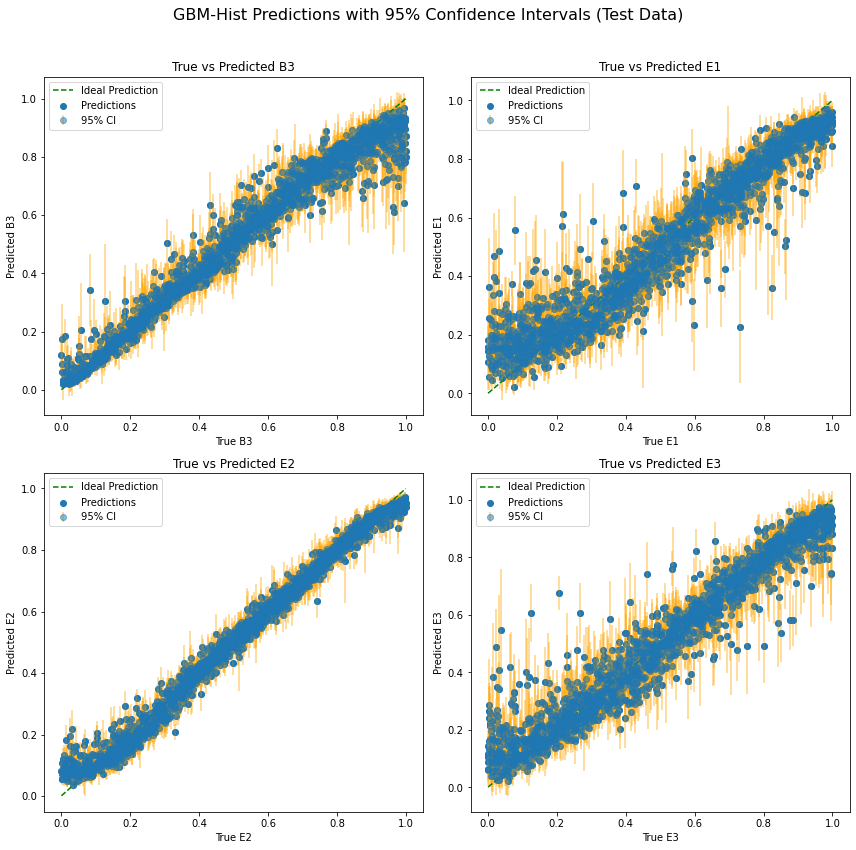

In [73]:
import matplotlib.pyplot as plt

# Plotting the results for each target (assuming target_data_test has 4 components)
num_targets = target_data_test.shape[1]
target_labels = ['B3', 'E1', 'E2', 'E3']  # Replace with appropriate labels for your targets

plt.figure(figsize=(12, 12))

for i in range(num_targets):
    plt.subplot(2, 2, i + 1)
    plt.scatter(target_data_test[:, i], mean_test[:, i], alpha=1, label='Predictions')
    plt.errorbar(target_data_test[:, i], mean_test[:, i], 
                 yerr=1.96 * std_dev_test[:, i], fmt='o', ecolor='orange',alpha=0.5, label='95% CI')
    plt.plot([target_data_test[:, i].min(), target_data_test[:, i].max()],
             [target_data_test[:, i].min(), target_data_test[:, i].max()],
             'g--', label='Ideal Prediction')
    plt.xlabel(f'True {target_labels[i]}')
    plt.ylabel(f'Predicted {target_labels[i]}')
    plt.title(f'True vs Predicted {target_labels[i]}')
    plt.legend()

plt.suptitle('GBM-Hist Predictions with 95% Confidence Intervals (Test Data)', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust layout to fit the title
figure_test_file = os.path.join("/home/botingl/machine learning", generate_filename("Predictions with 95% Confidence Intervals (Test Data)", "png"))
plt.savefig(figure_test_file, dpi=300, facecolor='white')
plt.show()
